# Training NTS Model

In [1]:
from machine_learning import MLModel
import json
import pandas as pd

In [2]:
path = "../data/MSASL_train.json"

data = pd.read_json(path, orient="records")
data["clean_text"].value_counts()

clean_text
eat            57
nice           54
want           53
teacher        50
orange         50
               ..
give ticket     1
purchase        1
ﬁre             1
acquire         1
dish            1
Name: count, Length: 1048, dtype: int64

In [3]:
# load data
data_path = "../data/v3"
train_data: list[dict] = []
test_data: list[dict] = []
val_data: list[dict] = []

words = ["eat", "nice", "want"]

types = ["train", "val", "test"]

for t in types:
  path = f"{data_path}/{t}"
  for word in words:
    file_path = f"{path}/{word}_{t}_dataset.json"
    with open(file_path, "r") as f:
      data = json.load(f)
      print(f"Number of samples in {word}-{t} is {len(data['frameData'])}")
      if t == "train":
        train_data.append(data)
      elif t == "test":
        test_data.append(data)
      elif t == "val":
        val_data.append(data)

Number of samples in eat-train is 37
Number of samples in nice-train is 38
Number of samples in want-train is 38
Number of samples in eat-val is 6
Number of samples in nice-val is 12
Number of samples in want-val is 4
Number of samples in eat-test is 4
Number of samples in nice-test is 5
Number of samples in want-test is 6


In [4]:
# setup model
num_classes = 3

model = MLModel(num_classes)

Model: "NTS_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 30, 44, 1, 32)  │        13,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 44, 1, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 30, 44, 1, 64)  │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 44, 1, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 30, 44, 1, 128) │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 44, 1, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 168960)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    21,627,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,011,267 (83.97 MB)

 Trainable params: 22,010,819 (83.96 MB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
# train model
model.train_model(train_data, test_data, val_data)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 428ms/step - accuracy: 0.4534 - loss: 9.7334 - val_accuracy: 0.2273 - val_loss: 1.1772
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step - accuracy: 0.8288 - loss: 7.5879 - val_accuracy: 0.1818 - val_loss: 1.8483
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 384ms/step - accuracy: 0.7625 - loss: 3.3510 - val_accuracy: 0.1818 - val_loss: 2.0262
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - accuracy: 0.8259 - loss: 1.8050 - val_accuracy: 0.5455 - val_loss: 1.4128
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step - accuracy: 0.8086 - loss: 2.2953 - val_accuracy: 0.1818 - val_loss: 1.9042
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 366ms/step - accuracy: 0.8317 - loss: 3.6991 - val_accuracy: 0.5455 - val_loss: 1.1341
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step - accuracy: 0.6919 - loss: 4.5054 - val_accuracy: 0.5455 - val_loss: 1.8885
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 353ms/step - accuracy: 0.7975 - loss: 3.8160 - val_accuracy: 0.1818 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
[[0.3579388  0.21918662 0.42287457]
 [0.37222418 0.21625368 0.41152215]
 [0.37240148 0.21671097 0.41088757]
 [0.37364718 0.21621822 0.41013452]
 [0.36526126 0.21590482 0.4188339 ]
 [0.36634788 0.21670765 0.4169444 ]
 [0.36290428 0.21526788 0.4218279 ]
 [0.36548638 0.21597938 0.41853422]
 [0.36597654 0.21594182 0.4180816 ]
 [0.36224836 0.21554065 0.422211  ]
 [0.36083493 0.21663271 0.42253238]
 [0.3629291  0.21666536 0.42040548]
 [0.36224252 0.21476048 0.422997  ]
 [0.36189982 0.2158451  0.42225513]
 [0.36179554 0.21625118 0.4219532 ]]
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00         5
           2       0.40      1.00      0.57         6

    accuracy                           0.40        15
   macro avg       0.13      0.33      0.19        15
weighted avg       0.16      0.40      0.23        15



/Users/hermanseternes/Documents/code/SL-dataset-automizer/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hermanseternes/Documents/code/SL-dataset-automizer/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hermanseternes/Documents/code/SL-dataset-automizer/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division`

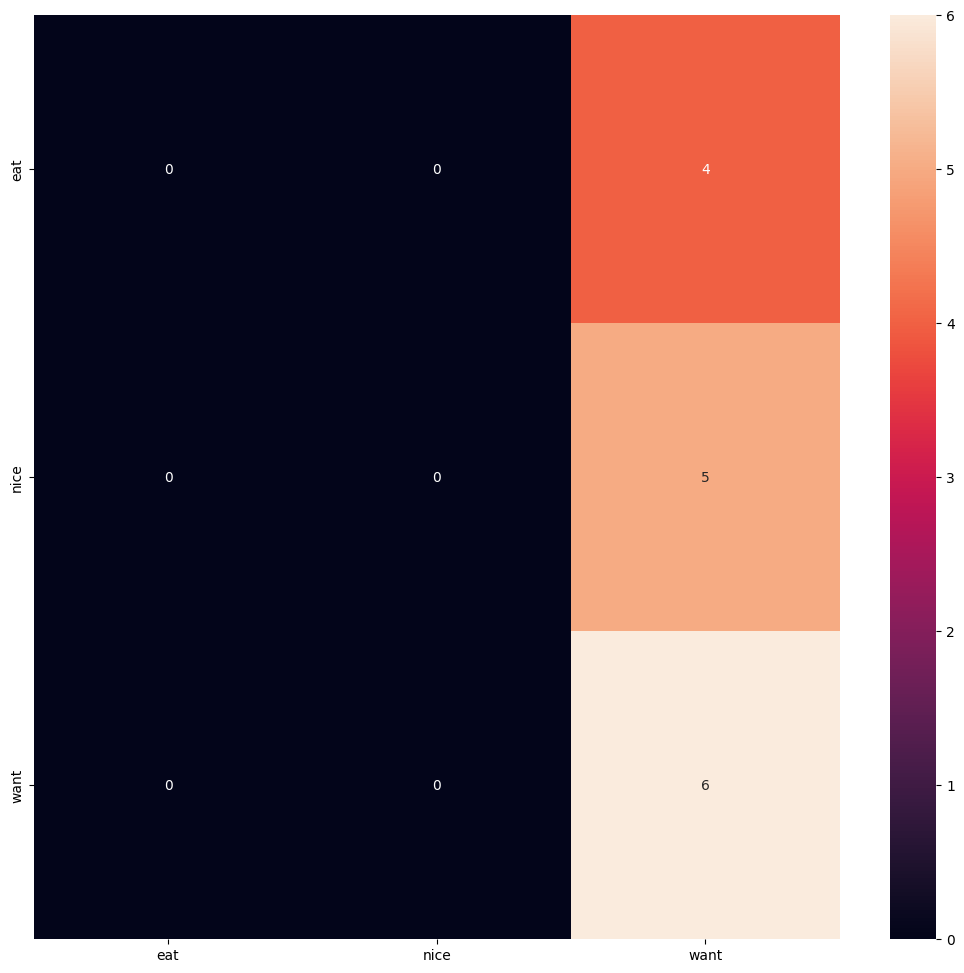

In [6]:
# print results
model.get_model_stats(labels=words)